
<h1 style="text-align: center;">Trabajo Práctico Nº 2</h1>

In [1]:
import cv2
import matplotlib.pyplot as plt
import os 
import numpy as np
from skimage import data, util, img_as_float
from skimage.util import random_noise
from skimage.restoration import denoise_bilateral, denoise_tv_chambolle

# Ejercicio 3

- **Consulta**:
Implementar el detector de bordes por el método del gradiente utilizando los
siguientes operadores de gradiente:
    - a) Prewitt
    - b) Sobel

- **Aplicar los operadores a tres imágenes diferentes**:
    1. Imagen satelital (Bariloche - Banda 4)
    2. Fotografía de un edificio
    3. Fotografía de un rostro

Respuesta:
Se implementan ambos operadores utilizando funciones definidas por el usuario
y se aplican a las tres imágenes para comparar su desempeño en distintos tipos
de escena. Se muestran los resultados obtenidos en cada caso.
"""


In [ ]:
# --------------------------
# FUNCIONES
# --------------------------

def aplicar_prewitt(img):
    """Aplica el operador de Prewitt a una imagen en escala de grises."""
    kernel_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
    kernel_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
    gx = cv2.filter2D(img, -1, kernel_x)
    gy = cv2.filter2D(img, -1, kernel_y)
    return np.hypot(gx, gy)

def aplicar_sobel(img):
    """Aplica el operador de Sobel a una imagen en escala de grises."""
    gx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    return np.hypot(gx, gy)

def mostrar_resultados(nombre_imagen, original, prewitt, sobel):
    """Muestra la imagen original, Prewitt y Sobel en una misma figura."""
    plt.figure(figsize=(12, 4))
    plt.suptitle(f"{nombre_imagen}", fontsize=14)

    plt.subplot(1, 3, 1)
    plt.imshow(original, cmap='gray')
    plt.title("Original")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(prewitt, cmap='gray')
    plt.title("Prewitt")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(sobel, cmap='gray')
    plt.title("Sobel")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

# --------------------------
# PROCESAMIENTO DE IMÁGENES
# --------------------------

imagenes = [
    ("Imagen Satelital", "imagenesEJ3/B4_bariloche.tif"),
    ("Edificio", "imagenesEJ3/edificio.jpg"),
    ("Rostro", "imagenesEJ3/rostro.jpg")
]

for nombre, ruta in imagenes:
    imagen = cv2.imread(ruta, cv2.IMREAD_GRAYSCALE)

    if imagen is None:
        print(f"Error al cargar la imagen: {ruta}")
        continue

    # Aplicar operadores
    prewitt = aplicar_prewitt(imagen)
    sobel = aplicar_sobel(imagen)

    # Mostrar resultados
    mostrar_resultados(nombre, imagen, prewitt, sobel)


Error al cargar la imagen: imagenes/B4_bariloche.tif
Error al cargar la imagen: imagenes/edificio.jpg
Error al cargar la imagen: imagenes/rostro.jpg


[ WARN:0@2013.927] global loadsave.cpp:268 findDecoder imread_('imagenes/B4_bariloche.tif'): can't open/read file: check file path/integrity
[ WARN:0@2013.927] global loadsave.cpp:268 findDecoder imread_('imagenes/edificio.jpg'): can't open/read file: check file path/integrity
[ WARN:0@2013.927] global loadsave.cpp:268 findDecoder imread_('imagenes/rostro.jpg'): can't open/read file: check file path/integrity


Implementar el detector de bordes por el método del gradiente utilizando los siguientes
operadores de gradiente:
    a) ** Prewitt**
    b) Sobel.

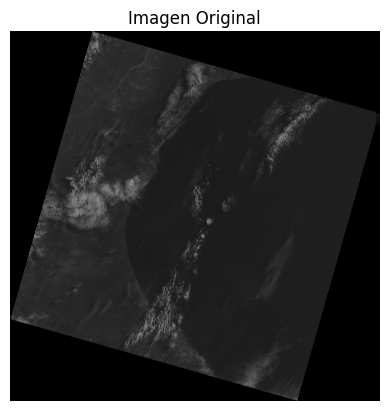

In [55]:
# Cargar la imagen en escala de grises
imagen = cv2.imread('rada_tilly/B3_8bit.tif', cv2.IMREAD_GRAYSCALE)

# Verificar si la imagen se cargó correctamente
if imagen is None:
    raise ValueError("No se pudo cargar la imagen. Verifica la ruta.")

# Aplicar el operador de Prewitt
# Crear kernels de Prewitt para la dirección x y la dirección y
kernel_prewitt_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
kernel_prewitt_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

prewitt_x = cv2.filter2D(imagen, -1, kernel_prewitt_x)
prewitt_y = cv2.filter2D(imagen, -1, kernel_prewitt_y)
prewitt = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)
# Aplicar el operador de Sobel
sobel_x = cv2.Sobel(imagen, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(imagen, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.addWeighted(np.abs(sobel_x), 0.5, np.abs(sobel_y), 0.5, 0)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.show()

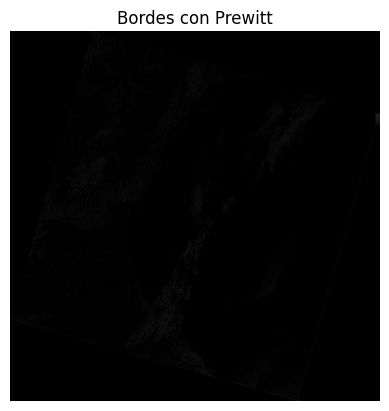

In [56]:
# Bordes con Prewitt
plt.imshow(prewitt, cmap='gray')
plt.title('Bordes con Prewitt')
plt.axis('off')
plt.show()

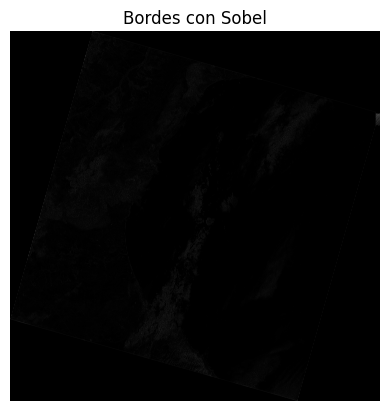

In [57]:
# Bordes con Sobel
plt.imshow(sobel, cmap='gray')
plt.title('Bordes con Sobel')
plt.axis('off')
plt.show()

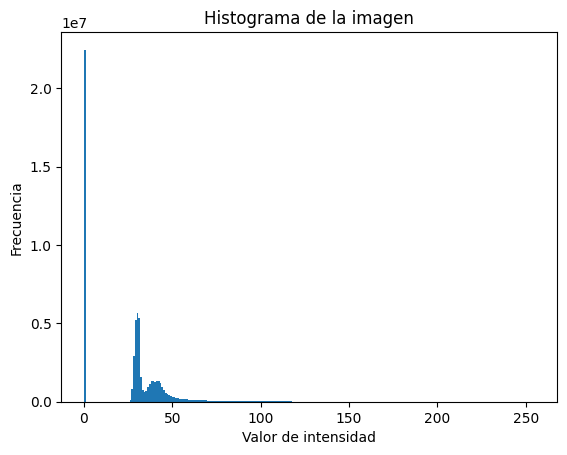

In [58]:
plt.hist(imagen.ravel(), bins=256)
plt.title("Histograma de la imagen")
plt.xlabel("Valor de intensidad")
plt.ylabel("Frecuencia")
plt.show()

### Análisis del contraste de la imagen y cambio de fuente

Inicialmente se intentó aplicar los detectores de bordes de **Prewitt** y **Sobel** sobre la imagen correspondiente a la **banda verde (B3)** de la escena Landsat 8 de la ciudad de **Rada Tilly**. Se probo tambien con la B4 y B5

Para evaluar si la imagen era adecuada para este tipo de análisis, se realizó un histograma de niveles de intensidad. Se observó que **la mayoría de los valores se encontraban concentrados entre 25 y 50**, lo que indica un **bajo contraste general** en la imagen.

Este bajo contraste tiene un impacto directo en la efectividad de los detectores de bordes por gradiente, ya que estos operadores se basan en la detección de diferencias de intensidad entre píxeles vecinos. Como resultado, las imágenes obtenidas tras aplicar los operadores de Prewitt y Sobel se veían oscuras y con escasa visibilidad de contornos.

#### Decisión metodológica

Debido a esta limitación, se decidió **utilizar las imágenes de la ciudad de Bariloche empleadas en el Trabajo Práctico 1**, las cuales presentaban mayor contraste y permitían visualizar de forma clara los contornos obtenidos con los operadores de gradiente. Esta decisión se tomó con el objetivo de garantizar una mejor interpretación visual de los resultados, sin alterar la validez del método.



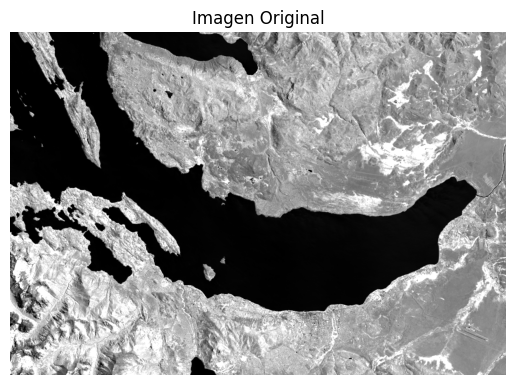

In [59]:
# Cargar la imagen en escala de grises
imagen = cv2.imread('imagenesbariloche/img5.tif', cv2.IMREAD_GRAYSCALE)

# Verificar si la imagen se cargó correctamente
if imagen is None:
    raise ValueError("No se pudo cargar la imagen. Verifica la ruta.")

# Aplicar el operador de Prewitt
# Crear kernels de Prewitt para la dirección x y la dirección y
kernel_prewitt_x = np.array([[1, 0, -1], [1, 0, -1], [1, 0, -1]])
kernel_prewitt_y = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])

prewitt_x = cv2.filter2D(imagen, -1, kernel_prewitt_x)
prewitt_y = cv2.filter2D(imagen, -1, kernel_prewitt_y)
prewitt = cv2.addWeighted(prewitt_x, 0.5, prewitt_y, 0.5, 0)
# Aplicar el operador de Sobel
sobel_x = cv2.Sobel(imagen, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(imagen, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.addWeighted(np.abs(sobel_x), 0.5, np.abs(sobel_y), 0.5, 0)
plt.imshow(imagen, cmap='gray')
plt.title('Imagen Original')
plt.axis('off')
plt.show()

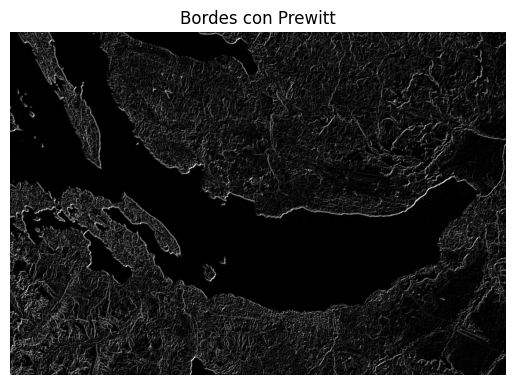

In [60]:
# Bordes con Prewitt
plt.imshow(prewitt, cmap='gray')
plt.title('Bordes con Prewitt')
plt.axis('off')
plt.show()

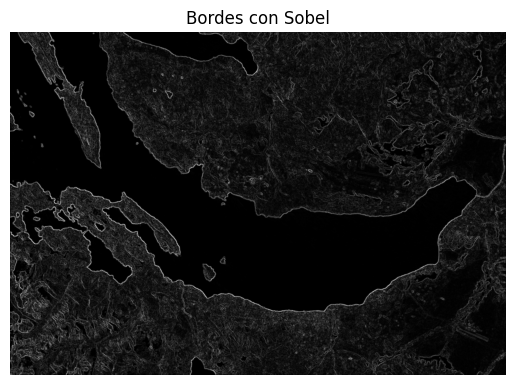

In [61]:
# Bordes con Sobel
plt.imshow(sobel, cmap='gray')
plt.title('Bordes con Sobel')
plt.axis('off')
plt.show()

En este caso, para la img 5 de Bariloche, tanto los bordes con Sobel como con Prewitt, se identifican mucho mas claramente que las imágenes de rada tilly utilzadas anteriormente. 

<hr>
<p style="text-align: center;">
Nombre: <strong>Sosa Suarez Santiago</strong><br>
Materia: <em>Análisis y Tratamiento de Imágenes Satelitales</em><br>
Maestría en Ciencia de Datos – <em>ITBA</em><br>
Fecha: 05 de Julio de 2025
</p>
<hr>